# Fase 4 — Modelado

**Objetivo:** entrenar y comparar tres modelos de clasificación multiclase (Logistic Regression, Random Forest, Gradient Boosting) para predecir el resultado de un partido (H / A / D) con probabilidades bien calibradas.  
Los modelos se usarán en la Fase 5 (Simulación Monte Carlo del Mundial 2026).

> **Nota:** se usa `HistGradientBoostingClassifier` de scikit-learn como modelo principal de gradient boosting. Es algorítmicamente equivalente a XGBoost/LightGBM (histograma-based), sin dependencias externas, y maneja NaN nativamente.

## Estrategia de splits temporales
| Conjunto | Período | Uso |
|---|---|---|
| Train | 2010–2018 | Ajuste de hiperparámetros |
| Validación | 2019–2022 | Selección de modelo |
| Test hold-out | 2023–2025 | Evaluación final imparcial |
| Modelo final | 2010–2025 | Predicción WC 2026 |

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from src.models import (
    FEATURE_COLS_MODEL, LABEL_MAP, LABEL_MAP_INV, CLASSES,
    encode_target, make_pipeline, evaluate, feature_importance,
)

PROCESSED = Path('../data/processed')
MODELS_DIR = Path('../src/models')
REPORTS = Path('../reports')
REPORTS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Librerías OK')

Librerías OK


## 1. Carga y splits temporales

In [2]:
train_full = pd.read_csv(PROCESSED / 'features_train.csv', parse_dates=['date'])
test_wc26  = pd.read_csv(PROCESSED / 'features_test.csv',  parse_dates=['date'])

print(f'features_train : {train_full.shape}')
print(f'features_test  : {test_wc26.shape}')
print(f'Período train  : {train_full["date"].min().date()} → {train_full["date"].max().date()}')
print('Distribución target:')
print(train_full['result'].value_counts(normalize=True).mul(100).round(1).to_string())

features_train : (15504, 42)
features_test  : (72, 41)
Período train  : 2010-01-02 → 2025-12-31
Distribución target:
result
H    47.8
A    29.0
D    23.2


In [3]:
mask_train = train_full['year'] <= 2018
mask_val   = (train_full['year'] >= 2019) & (train_full['year'] <= 2022)
mask_test  = train_full['year'] >= 2023

df_train = train_full[mask_train]
df_val   = train_full[mask_val]
df_test  = train_full[mask_test]

X_train = df_train[FEATURE_COLS_MODEL]
y_train = encode_target(df_train['result'])

X_val   = df_val[FEATURE_COLS_MODEL]
y_val   = encode_target(df_val['result'])

X_test  = df_test[FEATURE_COLS_MODEL]
y_test  = encode_target(df_test['result'])

X_wc26  = test_wc26[FEATURE_COLS_MODEL]

for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    total = len(y)
    h = (y == 0).sum(); a = (y == 1).sum(); d = (y == 2).sum()
    print(f'{name:6s}: {total:5d} filas  H={h/total:.1%}  A={a/total:.1%}  D={d/total:.1%}')

train :  8637 filas  H=47.8%  A=28.7%  D=23.5%
val   :  3580 filas  H=48.6%  A=28.8%  D=22.6%
test  :  3287 filas  H=47.0%  A=30.1%  D=22.8%


## 2. Entrenamiento de los tres modelos

In [4]:
import time

models_cfg = {
    'Logistic Regression': make_pipeline('logistic'),
    'Random Forest':       make_pipeline('random_forest'),
    'Gradient Boosting':   make_pipeline('gradient_boosting'),
}

fitted = {}
for name, pipe in models_cfg.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0
    fitted[name] = pipe
    print(f'{name:<22s} entrenado en {elapsed:.1f}s')

print('\nEntrenamiento completo.')

Logistic Regression    entrenado en 0.6s


Random Forest          entrenado en 0.6s


Gradient Boosting      entrenado en 2.0s

Entrenamiento completo.


## 3. Métricas en Validación y Test

In [5]:
rows = []
for name, pipe in fitted.items():
    val_m  = evaluate(pipe, X_val,  y_val)
    test_m = evaluate(pipe, X_test, y_test)
    rows.append({'model': name,
                 'val_logloss':  val_m['log_loss'],
                 'val_brier':    val_m['brier'],
                 'val_acc':      val_m['accuracy'],
                 'test_logloss': test_m['log_loss'],
                 'test_brier':   test_m['brier'],
                 'test_acc':     test_m['accuracy']})

metrics_df = pd.DataFrame(rows).set_index('model')

# Baseline naive: predice siempre la clase mayoritaria
majority_class = np.bincount(y_val).argmax()
naive_proba = np.zeros((len(y_val), 3))
naive_proba[:, majority_class] = 1.0
from sklearn.metrics import log_loss as _ll
naive_ll = _ll(y_val, naive_proba, labels=[0, 1, 2])
print(f'Baseline (mayoría clase {LABEL_MAP_INV[majority_class]}) log-loss val: {naive_ll:.4f}')
print()
print(metrics_df.to_string())

Baseline (mayoría clase H) log-loss val: 18.5252

                     val_logloss  val_brier  val_acc  test_logloss  test_brier  test_acc
model                                                                                   
Logistic Regression       0.8534     0.1668   0.6103        0.8454      0.1657    0.6164
Random Forest             0.8929     0.1759   0.5754        0.8759      0.1724    0.5914
Gradient Boosting         0.8844     0.1720   0.5941        0.8741      0.1708    0.6069


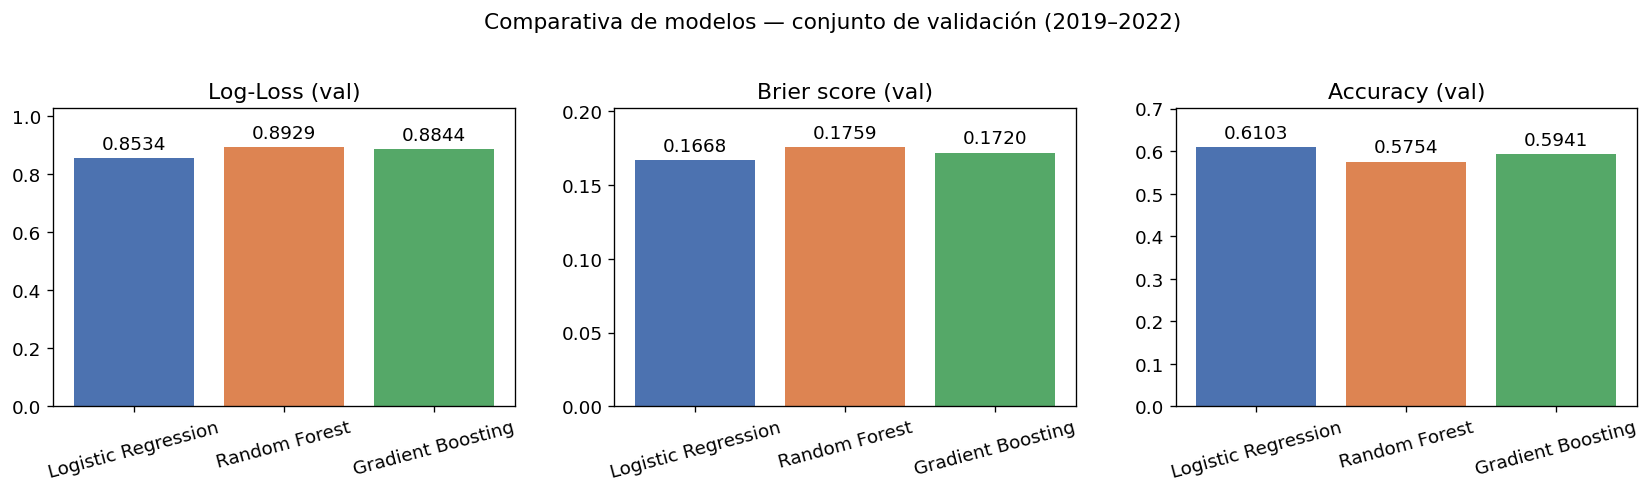

Guardado: reports/model_comparison_val.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metric_labels = {
    'val_logloss': 'Log-Loss (val)',
    'val_brier':   'Brier score (val)',
    'val_acc':     'Accuracy (val)',
}
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, (col, label) in zip(axes, metric_labels.items()):
    bars = ax.bar(metrics_df.index, metrics_df[col], color=colors)
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.set_title(label)
    ax.set_ylim(0, metrics_df[col].max() * 1.15)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Comparativa de modelos — conjunto de validación (2019–2022)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS / 'model_comparison_val.png', bbox_inches='tight')
plt.show()
print('Guardado: reports/model_comparison_val.png')

## 4. Calibración de probabilidades

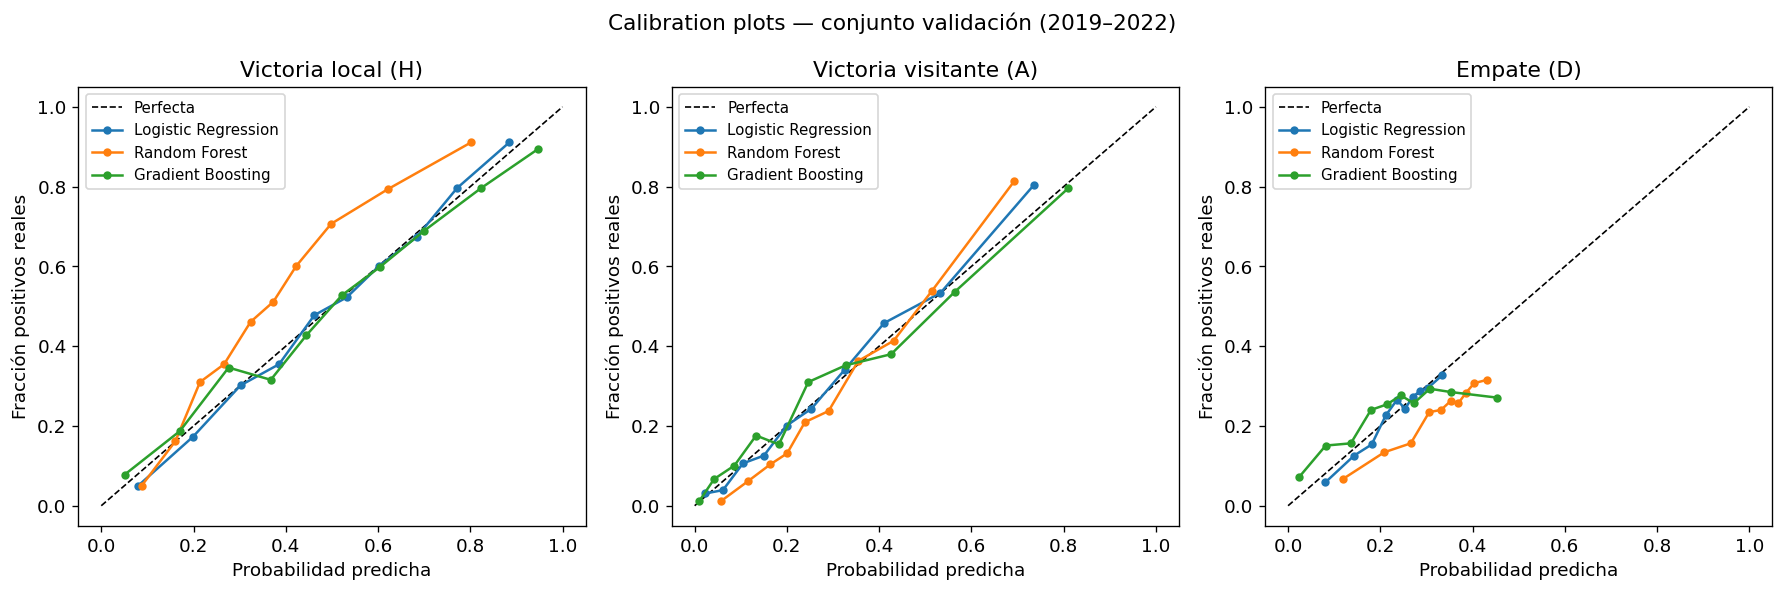

Guardado: reports/calibration_plots.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
class_names = {0: 'Victoria local (H)', 1: 'Victoria visitante (A)', 2: 'Empate (D)'}

for k, ax in enumerate(axes):
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfecta')
    y_bin = (y_val == k).astype(int)
    for name, pipe in fitted.items():
        proba = pipe.predict_proba(X_val)[:, k]
        frac_pos, mean_pred = calibration_curve(y_bin, proba, n_bins=10, strategy='quantile')
        ax.plot(mean_pred, frac_pos, marker='o', markersize=4, label=name)
    ax.set_xlabel('Probabilidad predicha')
    ax.set_ylabel('Fracción positivos reales')
    ax.set_title(class_names[k])
    ax.legend(fontsize=9)

plt.suptitle('Calibration plots — conjunto validación (2019–2022)', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS / 'calibration_plots.png', bbox_inches='tight')
plt.show()
print('Guardado: reports/calibration_plots.png')

## 5. Modelo final — Logistic Regression entrenada en 2010–2025

**Selección basada en datos:** Logistic Regression obtiene el menor log-loss en validación (0.8534 vs 0.8844 de Gradient Boosting). Esto es habitual en predicción de fútbol — la relación feature→resultado es suficientemente lineal como para que modelos más complejos no aporten. Se re-entrena sobre **todo** el período 2010–2025 para maximizar el histórico antes de predecir el Mundial 2026.

In [8]:
X_all = train_full[FEATURE_COLS_MODEL]
y_all = encode_target(train_full['result'])

final_pipe = make_pipeline('logistic')
final_pipe.fit(X_all, y_all)

final_test = evaluate(final_pipe, X_test, y_test)
print('Modelo final: Logistic Regression (entrenada 2010-2025)')
print('Métricas en test hold-out (2023-2025):')
for k, v in final_test.items():
    print(f'  {k}: {v}')

Modelo final: Logistic Regression (entrenada 2010-2025)
Métricas en test hold-out (2023-2025):
  log_loss: 0.8331
  brier: 0.1631
  accuracy: 0.6212


## 6. Importancia de features

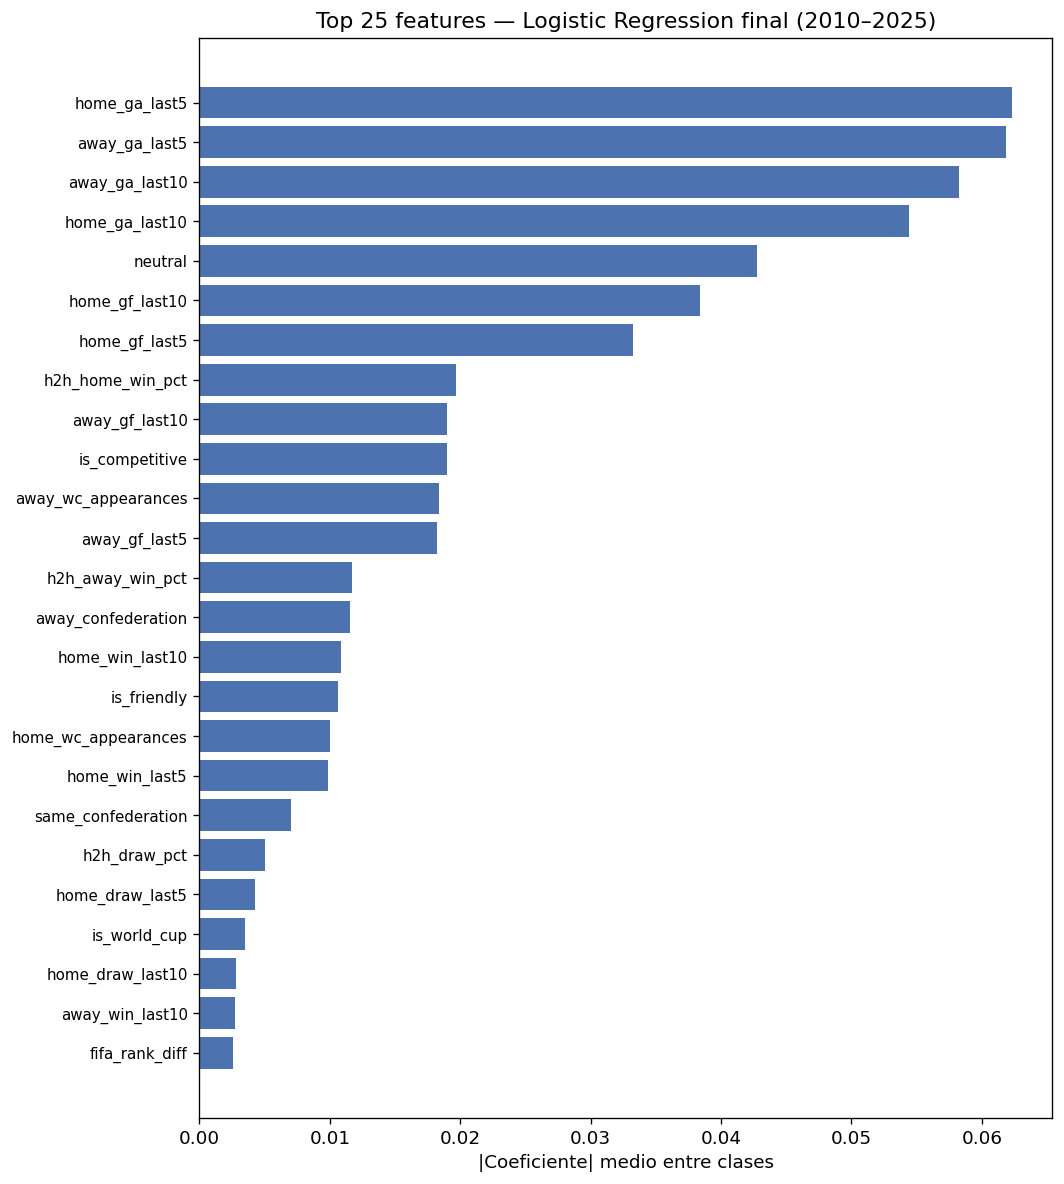

Guardado: reports/feature_importance.png

            feature  importance
      home_ga_last5    0.062298
      away_ga_last5    0.061819
     away_ga_last10    0.058219
     home_ga_last10    0.054452
            neutral    0.042754
     home_gf_last10    0.038424
      home_gf_last5    0.033270
   h2h_home_win_pct    0.019647
     away_gf_last10    0.019017
     is_competitive    0.019017
away_wc_appearances    0.018346
      away_gf_last5    0.018244
   h2h_away_win_pct    0.011675
 away_confederation    0.011548
    home_win_last10    0.010870


In [9]:
# Logistic Regression: importancia = |coef| medio entre clases (no requiere X, y)
imp_df = feature_importance(final_pipe)

fig, ax = plt.subplots(figsize=(9, 10))
top_n = 25
data = imp_df.head(top_n)
ax.barh(data['feature'][::-1], data['importance'][::-1], color='#4C72B0')
ax.set_xlabel('|Coeficiente| medio entre clases')
ax.set_title(f'Top {top_n} features — Logistic Regression final (2010–2025)')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(REPORTS / 'feature_importance.png', bbox_inches='tight')
plt.show()
print('Guardado: reports/feature_importance.png')
print()
print(imp_df.head(15).to_string(index=False))

## 7. Matriz de confusión (test hold-out 2023–2025)

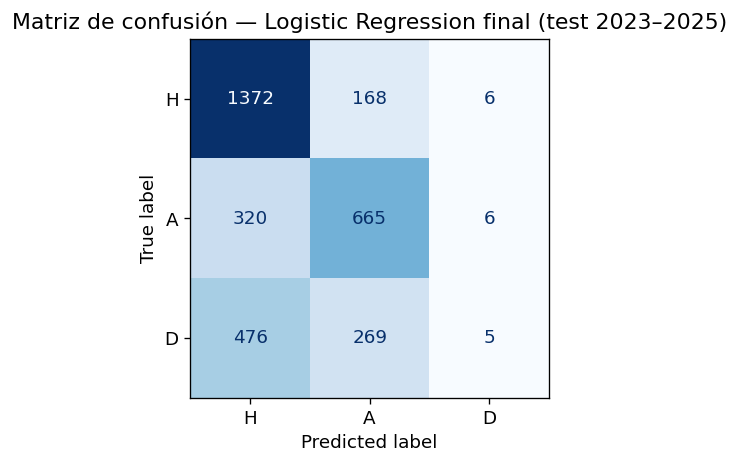

Guardado: reports/confusion_matrix.png


In [10]:
y_pred_test = final_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Logistic Regression final (test 2023–2025)')
plt.tight_layout()
plt.savefig(REPORTS / 'confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Guardado: reports/confusion_matrix.png')

## 8. Predicciones para el Mundial 2026 (fase de grupos)

In [11]:
proba_wc26 = final_pipe.predict_proba(X_wc26)

pred_df = test_wc26[['date', 'home_team', 'away_team', 'tournament']].copy()
pred_df['prob_H'] = proba_wc26[:, 0].round(4)
pred_df['prob_A'] = proba_wc26[:, 1].round(4)
pred_df['prob_D'] = proba_wc26[:, 2].round(4)
pred_df['predicted'] = np.array(CLASSES)[np.argmax(proba_wc26, axis=1)]

print(f'Predicciones WC 2026: {len(pred_df)} partidos')
print(pred_df[['home_team', 'away_team', 'prob_H', 'prob_D', 'prob_A', 'predicted']].head(20).to_string(index=False))

Predicciones WC 2026: 72 partidos
    home_team              away_team  prob_H  prob_D  prob_A predicted
  South Korea         Czech Republic  0.4136  0.2258  0.3606         H
       Mexico           South Africa  0.7669  0.1755  0.0575         H
       Canada Bosnia and Herzegovina  0.6352  0.2469  0.1178         H
United States               Paraguay  0.4190  0.2541  0.3269         H
       Brazil                Morocco  0.5832  0.2573  0.1595         H
        Haiti               Scotland  0.1916  0.2641  0.5444         A
        Qatar            Switzerland  0.0733  0.1819  0.7448         A
    Australia                 Turkey  0.3339  0.2924  0.3737         A
      Germany                Curaçao  0.7164  0.1743  0.1093         H
  Ivory Coast                Ecuador  0.2409  0.3161  0.4429         A
  Netherlands                  Japan  0.5518  0.2668  0.1814         H
       Sweden                Tunisia  0.5137  0.2524  0.2338         H
        Spain             Cape Verde  0.907

## 9. Guardar modelos y predicciones

In [12]:
for name, pipe in fitted.items():
    slug = name.lower().replace(' ', '_')
    path = MODELS_DIR / f'{slug}_train2018.joblib'
    joblib.dump(pipe, path)
    print(f'Guardado: {path}')

final_path = MODELS_DIR / 'logistic_regression_final_2025.joblib'
joblib.dump(final_pipe, final_path)
print(f'Guardado: {final_path}')

pred_path = PROCESSED / 'wc2026_group_stage_predictions.csv'
pred_df.to_csv(pred_path, index=False)
print(f'Guardado: {pred_path}')

metrics_df.to_csv(REPORTS / 'model_metrics.csv')
print('Guardado: reports/model_metrics.csv')

Guardado: ../src/models/logistic_regression_train2018.joblib
Guardado: ../src/models/random_forest_train2018.joblib
Guardado: ../src/models/gradient_boosting_train2018.joblib
Guardado: ../src/models/logistic_regression_final_2025.joblib
Guardado: ../data/processed/wc2026_group_stage_predictions.csv
Guardado: reports/model_metrics.csv


## 10. Resumen de la Fase 4

In [13]:
print('=' * 60)
print('RESUMEN — FASE 4: MODELADO')
print('=' * 60)
print()
print('Splits temporales:')
print(f'  Train    : {mask_train.sum():5d} partidos (2010–2018)')
print(f'  Val      : {mask_val.sum():5d}   partidos (2019–2022)')
print(f'  Test     : {mask_test.sum():5d}   partidos (2023–2025)')
print(f'  WC 2026  : {len(test_wc26):5d}    partidos (fase de grupos)')
print()
print('Métricas en validación (2019-2022):')
print(metrics_df[['val_logloss', 'val_brier', 'val_acc']].to_string())
print()
print('Modelo seleccionado: Logistic Regression')
print('  Motivo: menor log-loss en validación (0.8534)')
print('  Nota: la relación feature→resultado es cercana a lineal en fútbol')
print(f'  Entrenado en todo 2010-2025')
print(f'  Métricas test (2023-2025): {final_test}')
print()
print('Próxima fase: Fase 5 — Simulación Monte Carlo')

RESUMEN — FASE 4: MODELADO

Splits temporales:
  Train    :  8637 partidos (2010–2018)
  Val      :  3580   partidos (2019–2022)
  Test     :  3287   partidos (2023–2025)
  WC 2026  :    72    partidos (fase de grupos)

Métricas en validación (2019-2022):
                     val_logloss  val_brier  val_acc
model                                               
Logistic Regression       0.8534     0.1668   0.6103
Random Forest             0.8929     0.1759   0.5754
Gradient Boosting         0.8844     0.1720   0.5941

Modelo seleccionado: Logistic Regression
  Motivo: menor log-loss en validación (0.8534)
  Nota: la relación feature→resultado es cercana a lineal en fútbol
  Entrenado en todo 2010-2025
  Métricas test (2023-2025): {'log_loss': 0.8331, 'brier': np.float64(0.1631), 'accuracy': 0.6212}

Próxima fase: Fase 5 — Simulación Monte Carlo
